In [1]:
# Instala o SpaCy, Transformers e SentenceTransformers (ideal para embeddings)
!pip install -q spacy transformers sentence-transformers scikit-learn matplotlib seaborn
!python -m spacy download pt_core_news_sm -q

import pandas as pd
import spacy
from spacy.training.example import Example
import random
import warnings
warnings.filterwarnings("ignore")

print("Bibliotecas carregadas com sucesso!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 93.7 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

In [2]:
caminho_arquivo = '/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv' 

# Lendo os dados COM A CODIFICAÇÃO CORRETA para ler os acentos (latin1)
df = pd.read_csv(caminho_arquivo, sep='\t', encoding='latin1')

# Limpando linhas vazias na descrição
df = df.dropna(subset=['Descricao_pública'])
textos = df['Descricao_pública'].tolist()

print(f"Total de projetos carregados: {len(textos)}")
display(df.head(2))

Total de projetos carregados: 2721


,Título_Público,Descricao_pública
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...


In [3]:
# 1. Definindo dados de treinamento manuais
# 1. Definindo dados de treinamento mais ricos
TRAIN_DATA = [
    ("Açúcar de frutas e aplicação em bolos como substituto da sacarose", {"entities": [(0, 16, "PRODUTO"), (57, 65, "COMPONENTE")]}),
    ("desenvolver uma tecnologia inovadora que possibilite à Suzano mapear", {"entities": [(55, 61, "EMPRESA")]}),
    ("otimizar o planejamento florestal presente no contexto da Klabin.", {"entities": [(58, 64, "EMPRESA")]}),
    ("contribuem para o desenvolvimento da bioeconomia no Brasil.", {"entities": [(52, 58, "LOCAL"), (37, 48, "AREA_ESTUDO")]}),
    ("gestão e governança do estoque e do sequestro de carbono", {"entities": [(36, 56, "METRICA_AMBIENTAL")]}),
    ("uso de inovações tecnológicas auxilia as indústrias", {"entities": [(7, 29, "TECNOLOGIA")]}),
    ("produzir frutose em pó que substitua a sacarose", {"entities": [(9, 22, "PRODUTO"), (39, 47, "COMPONENTE")]}),
    ("linha de farofas com castanhas brasileiras e adição de proteína animal", {"entities": [(21, 42, "INGREDIENTE"), (55, 70, "INGREDIENTE")]}),
    ("produtos oriundos das florestas brasileiras", {"entities": [(22, 43, "RECURSO_NATURAL")]}),
    ("diversidade da flora dos fragmentos avaliados", {"entities": [(15, 20, "RECURSO_NATURAL")]})
]

# 2. Criando o modelo SpaCy em branco para português
nlp_treino = spacy.blank("pt")

# 3. Adicionando o pipeline de Reconhecimento de Entidades Nomeadas (NER)
if "ner" not in nlp_treino.pipe_names:
    ner = nlp_treino.add_pipe("ner", last=True)

# 4. Adicionando as labels (categorias) que criamos acima
for _, annotations in TRAIN_DATA:
    for ent in annotations.get("entities"):
        ner.add_label(ent[2])

# 5. Loop de Treinamento
print("Iniciando o treinamento do modelo SpaCy...")
optimizer = nlp_treino.begin_training()
for itn in range(30): # 30 Épocas de treinamento
    random.shuffle(TRAIN_DATA)
    losses = {}
    for text, annotations in TRAIN_DATA:
        doc = nlp_treino.make_doc(text)
        example = Example.from_dict(doc, annotations)
        nlp_treino.update([example], drop=0.3, sgd=optimizer, losses=losses)
        
print("Treinamento finalizado!")

# 6. SALVANDO O MODELO (Requisito da sua tarefa)
nlp_treino.to_disk("./meu_modelo_ner_dl2024")
print("Modelo salvo na pasta './meu_modelo_ner_dl2024'")

Iniciando o treinamento do modelo SpaCy...
Treinamento finalizado!
Modelo salvo na pasta './meu_modelo_ner_dl2024'


In [6]:
# FAZENDO O LOAD (Requisito da sua tarefa)
nlp_carregado = spacy.load("./meu_modelo_ner_dl2024")

# Extraindo entidades dos primeiros 100 textos (para rodar rápido no teste)
todas_entidades = []
for texto in textos[:300]:
    doc = nlp_carregado(texto)
    for ent in doc.ents:
        todas_entidades.append(ent.text)

# Removendo palavras repetidas
# Filtra palavras com menos de 4 letras e remove pontuações indesejadas
entidades_unicas = list(set([
    e.strip().lower() for e in todas_entidades 
    if len(e.strip()) > 3 and not any(char in e for char in ['.', ',', '!', '?', '-'])
]))

Carregando o modelo Transformer BERT (Português)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gerando os embeddings matemáticos...


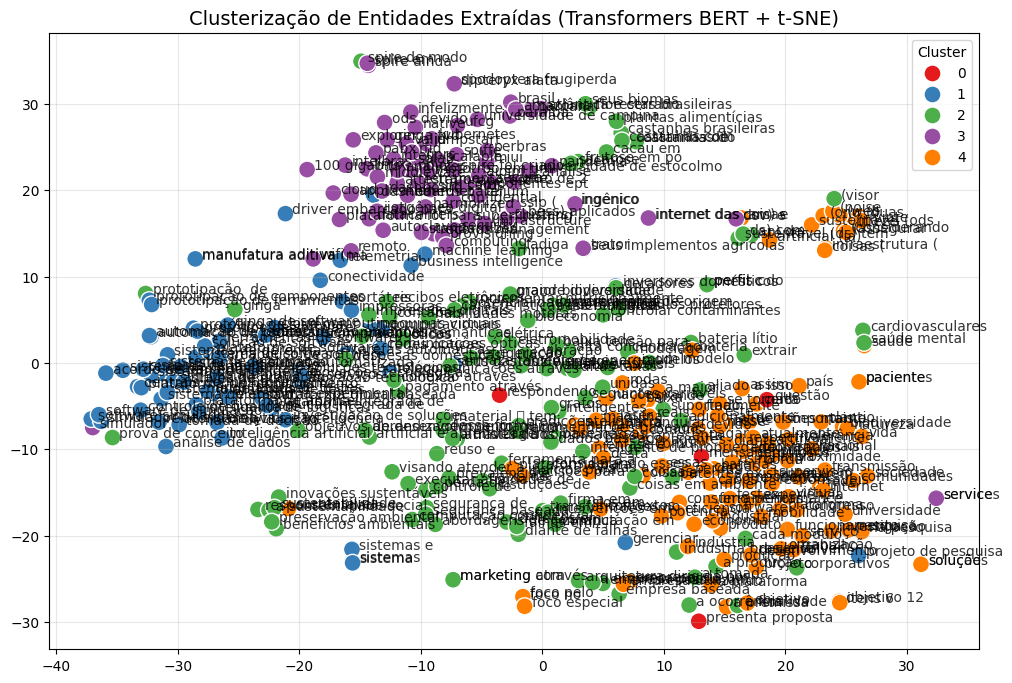

In [8]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Verificar se temos entidades suficientes para o gráfico
if len(entidades_unicas) >= 3:
    print("Carregando o modelo Transformer BERT (Português)...")
    # Forçando CPU para não dar o erro de placa de vídeo de antes
    modelo_transformer = SentenceTransformer('neuralmind/bert-base-portuguese-cased', device='cpu')
    
    print("Gerando os embeddings matemáticos...")
    embeddings = modelo_transformer.encode(entidades_unicas)

    # 1. CLUSTERIZAÇÃO com K-MEANS
    num_clusters = min(5, len(entidades_unicas) // 3) 
    if num_clusters < 2: num_clusters = 2
        
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    clusters = kmeans.fit_predict(embeddings)

    # 2. REDUÇÃO DE DIMENSIONALIDADE com t-SNE
    perplexity_value = min(15, len(entidades_unicas) - 1) 
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_value, init='pca')
    
    # ---> ESTA É A LINHA QUE FALTAVA NA MENSAGEM ANTERIOR <---
    embeddings_2d = tsne.fit_transform(embeddings)

    # 3. PLOTANDO O GRÁFICO (Visualização)
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=clusters, palette="Set1", s=150)

    # Colocando os textos das entidades ao lado das "bolinhas" do gráfico
    for i, entidade in enumerate(entidades_unicas):
        plt.annotate(entidade, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                     fontsize=10, alpha=0.8, xytext=(5,0), textcoords='offset points')

    plt.title("Clusterização de Entidades Extraídas (Transformers BERT + t-SNE)", fontsize=14)
    plt.legend(title="Cluster")
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("O modelo não encontrou entidades suficientes. Adicione mais exemplos no TRAIN_DATA na Célula 3!")